In [7]:
import os

os.listdir('/kaggle/input')

['datasets']

In [10]:
import os

os.listdir('/kaggle/input/datasets')

['redwankarimsony']

In [11]:
os.listdir('/kaggle/input/datasets/redwankarimsony')

['heart-disease-data']

In [12]:
os.listdir('/kaggle/input/datasets/redwankarimsony/heart-disease-data')

['heart_disease_uci.csv']

In [13]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv'
)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [14]:
print(df.shape)

df.info()

df.describe()

(920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [15]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [16]:
# حذف الصفوف التي تحتوي قيم ناقصة

df = df.dropna()

print(df.shape)

(299, 16)


In [17]:
# تحويل num إلى 0 و 1

df['num'] = df['num'].apply(
    lambda x: 0 if x == 0 else 1
)

print(df['num'].value_counts())

num
0    160
1    139
Name: count, dtype: int64


In [20]:
X = df.drop('num', axis=1)

y = df['num']

In [21]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   id  age  trestbps   chol  thalch  oldpeak   ca  sex_Male  dataset_Hungary  \
0   1   63     145.0  233.0   150.0      2.3  0.0      True            False   
1   2   67     160.0  286.0   108.0      1.5  3.0      True            False   
2   3   67     120.0  229.0   129.0      2.6  2.0      True            False   
3   4   37     130.0  250.0   187.0      3.5  0.0      True            False   
4   5   41     130.0  204.0   172.0      1.4  0.0     False            False   

   dataset_VA Long Beach  ...  cp_non-anginal  cp_typical angina  fbs_True  \
0                  False  ...           False               True      True   
1                  False  ...           False              False     False   
2                  False  ...           False              False     False   
3                  False  ...            True              False     False   
4                  False  ...           False              False     False   

   restecg_normal  restecg_st-t abnormality  exang

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ================================
# Scaling
# ================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ================================
# Logistic Regression
# ================================

log_model = LogisticRegression(
    max_iter=5000
)

log_model.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred = log_model.predict(
    X_test_scaled
)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8833333333333333


# Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(
    y_test,
    tree_pred
)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.85


# LDA

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

lda_pred = lda_model.predict(X_test)

lda_acc = accuracy_score(
    y_test,
    lda_pred
)

print("LDA Accuracy:", lda_acc)

LDA Accuracy: 0.8833333333333333


# Cross Validation

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average Accuracy:")
print(cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores:
[0.85       0.9        0.78333333 0.81666667 0.77966102]
Average Accuracy:
0.8259322033898304


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Bootstrap

In [35]:
import numpy as np

from sklearn.utils import resample
from sklearn.metrics import accuracy_score

bootstrap_scores = []

for i in range(100):

    X_boot, y_boot = resample(
        X_train_scaled,
        y_train,
        replace=True,
        random_state=i
    )

    log_model.fit(X_boot, y_boot)

    y_pred_boot = log_model.predict(X_test_scaled)

    acc = accuracy_score(
        y_test,
        y_pred_boot
    )

    bootstrap_scores.append(acc)

print("Bootstrap Mean Accuracy:")

print(np.mean(bootstrap_scores))

Bootstrap Mean Accuracy:
0.8759999999999999


# Metrics

In [37]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.875
Recall: 0.84
F1 Score: 0.8571428571428571


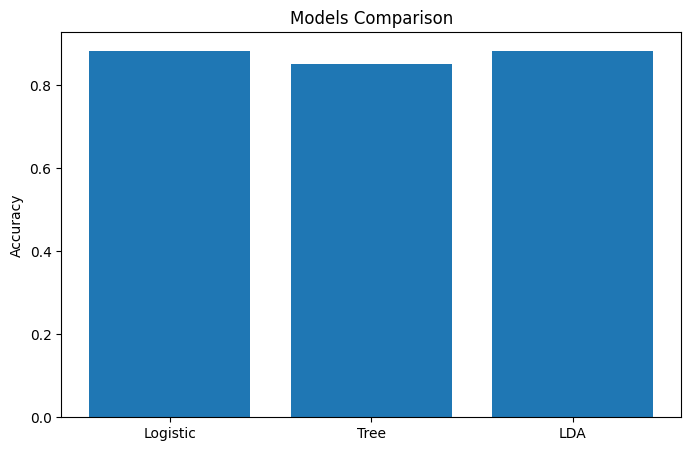

In [38]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Tree', 'LDA']

scores = [
    accuracy,
    tree_acc,
    lda_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Models Comparison")

plt.ylabel("Accuracy")

plt.show()